# Buổi 4: Tìm kiếm trong không gina trạng thái

## Bài 3: Trò chơi 8-Puzzles
Cho bàn cờ độ rộng 3 x 3 chứa 8 con số từ 1 đến 8 và 1 ô trống xuất hiện ngẫu nhiên. <br>

Hãy xếp thứ tự các con số tăng dần từ 1 đến 8 theo chiều từ trái sang phải và từ trên xuống dưới.<br>

![image](puzzle.png)


## 0. Đọc dữ liệu

**puzzle.inp**
```
4 8 1       # trạng thái đầu
6 3 0
2 7 5
1 2 3       # trạng thái đích
4 5 6
7 8 0
```

In [1]:
from ex3_puzzle import readfile
import pprint

start, goal = readfile()

pprint.pprint(start)
pprint.pprint(goal)

[((4, 8, 1), (6, 3, 0), (2, 7, 5))]
[((1, 2, 3), (4, 5, 6), (7, 8, 0))]


## 1. Giải puzzle bằng thuật toán BFS

### a. Cài đặt thuật toán

In [2]:
from ex3_puzzle import solve_BFS, print_step

end_state, cnt1 = solve_BFS(start, goal)

steps = print_step(end_state)

pprint.pprint(steps)

[[((4, 8, 1), (6, 3, 0), (2, 7, 5))],
 [((4, 8, 1), (6, 0, 3), (2, 7, 5))],
 [((4, 0, 1), (6, 8, 3), (2, 7, 5))],
 [((4, 1, 0), (6, 8, 3), (2, 7, 5))],
 [((4, 1, 3), (6, 8, 0), (2, 7, 5))],
 [((4, 1, 3), (6, 0, 8), (2, 7, 5))],
 [((4, 1, 3), (0, 6, 8), (2, 7, 5))],
 [((4, 1, 3), (2, 6, 8), (0, 7, 5))],
 [((4, 1, 3), (2, 6, 8), (7, 0, 5))],
 [((4, 1, 3), (2, 6, 8), (7, 5, 0))],
 [((4, 1, 3), (2, 6, 0), (7, 5, 8))],
 [((4, 1, 3), (2, 0, 6), (7, 5, 8))],
 [((4, 1, 3), (0, 2, 6), (7, 5, 8))],
 [((0, 1, 3), (4, 2, 6), (7, 5, 8))],
 [((1, 0, 3), (4, 2, 6), (7, 5, 8))],
 [((1, 2, 3), (4, 0, 6), (7, 5, 8))],
 [((1, 2, 3), (4, 5, 6), (7, 0, 8))],
 [((1, 2, 3), (4, 5, 6), (7, 8, 0))]]


### b. Số trạng thái thực sự khi tới đích:

In [3]:
print(len(steps))

18


### c. Số trạng thái mở rộng của thuật toán 

In [4]:
print(cnt1)

47973


### d. Mô phỏng các bước

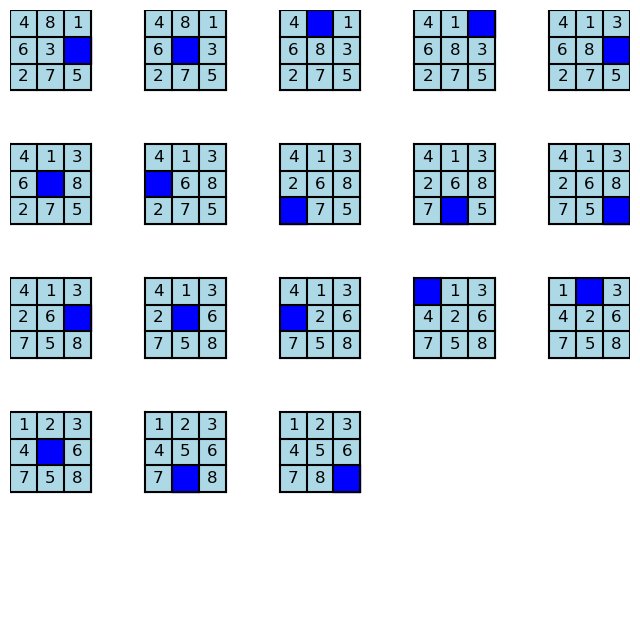

In [5]:
import matplotlib.pyplot as plt
def draw_step(state, x=0, y=0):
    s = state.state
    n = len(s)
    for i in range(n+1):
        plt.plot([x, x+n],
                 [y+i, y+i], color='black')
        plt.plot([x+i, x+i],
                 [y, y+n], color='black')

    for i in range(3):
        for j in range(3):
            value = s[i][j]
            if value != 0:
                plt.fill([x+j, x+j+1, x+j+1, x+j],[y+n-i, y+n-i, y+n-i-1, y+n-i-1],color='lightblue')
                plt.text(x + j + 0.5, y + n- i -0.5, str(value), ha='center', va='center', fontsize=12)
            else:
                plt.fill([x+j, x+j+1, x+j+1, x+j],[y+n-i, y+n-i, y+n-i-1, y+n-i-1],color='blue')

def simulation(steps):
    size = 23
    plt.figure(figsize=(8,8))
    plt.xlim(0,size)
    plt.ylim(0,size)
    plt.axis("off")

    x_start = 0
    y_start = size - 3
    cnt = 0

    for state in steps:
        if cnt % 5 == 0 and cnt != 0:
            x_start = 0
            y_start -= 5
        if state is None: continue
        draw_step(state, x_start, y_start)
        cnt += 1
        x_start += 5

        

simulation(steps)
plt.savefig("puzzle_bfs.png")
plt.show()

## 2. Giải puzzle bằng thuật toán DFS

### a. Cài đặt thuật toán

In [6]:
from ex3_puzzle import solve_DFS

state2, cnt2 = solve_DFS(start, goal)

step2 = print_step(state2)

pprint.pprint(step2)

[[((4, 8, 1), (6, 3, 0), (2, 7, 5))],
 [((4, 8, 1), (6, 0, 3), (2, 7, 5))],
 [((4, 8, 1), (0, 6, 3), (2, 7, 5))],
 [((4, 8, 1), (2, 6, 3), (0, 7, 5))],
 [((4, 8, 1), (2, 6, 3), (7, 0, 5))],
 [((4, 8, 1), (2, 6, 3), (7, 5, 0))],
 [((4, 8, 1), (2, 6, 0), (7, 5, 3))],
 [((4, 8, 1), (2, 0, 6), (7, 5, 3))],
 [((4, 8, 1), (0, 2, 6), (7, 5, 3))],
 [((4, 8, 1), (7, 2, 6), (0, 5, 3))],
 [((4, 8, 1), (7, 2, 6), (5, 0, 3))],
 [((4, 8, 1), (7, 2, 6), (5, 3, 0))],
 [((4, 8, 1), (7, 2, 0), (5, 3, 6))],
 [((4, 8, 1), (7, 0, 2), (5, 3, 6))],
 [((4, 8, 1), (0, 7, 2), (5, 3, 6))],
 [((4, 8, 1), (5, 7, 2), (0, 3, 6))],
 [((4, 8, 1), (5, 7, 2), (3, 0, 6))],
 [((4, 8, 1), (5, 7, 2), (3, 6, 0))],
 [((4, 8, 1), (5, 7, 0), (3, 6, 2))],
 [((4, 8, 1), (5, 0, 7), (3, 6, 2))],
 [((4, 8, 1), (0, 5, 7), (3, 6, 2))],
 [((4, 8, 1), (3, 5, 7), (0, 6, 2))],
 [((4, 8, 1), (3, 5, 7), (6, 0, 2))],
 [((4, 8, 1), (3, 5, 7), (6, 2, 0))],
 [((4, 8, 1), (3, 5, 0), (6, 2, 7))],
 [((4, 8, 1), (3, 0, 5), (6, 2, 7))],
 [((4, 8, 1)

### b. Số trạng thực sự khi tới đích

In [7]:
print(len(step2))

66016


### c. Số trạng thái mở rộng của thuật toán

In [8]:
print(cnt2)

272989


# Kết thúc